## Space-time overlay

:class:`~skmap.overlay.SpaceTimeOverlay` slices the catalogue by date range
(via :meth:`~skmap.io.RasterData.filter_date`) and, for each range, samples
the matching raster layers at the point locations.  The result is a table
with the original columns plus one column per raster feature (season name).


## Setup

We start by importing the modules used in this tutorial.

In [1]:
import os

os.environ["PROJ_LIB"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"
os.environ["PROJ_DATA"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"

In [2]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from skmap.io import RasterData
from skmap.data import toy
from skmap.overlay import SpaceTimeOverlay

## Dataset

The toy dataset ships a set of **land-cover training points** (`samples.gpkg`) and a
few raster layers covering the same 256 x 256 grid (EPSG:3035):

- `static/elev` and `static/slope` — static terrain layers,
- `ndvi/filled` and `swir1` — quarterly Landsat composites (2014-2020).

Let's load the training points.

In [3]:
samples = toy.lc_samples()
samples.head()

,date,label,code,target,geometry
0,2019-01-01,Non-irrigated arable land,211,12,POINT (4027365.527 3213354.075)
1,2019-01-01,Non-irrigated arable land,211,12,POINT (4023031.781 3217702.786)
2,2019-01-01,Pastures,231,18,POINT (4025421.04 3210923.411)
3,2019-01-01,Road and rail networks and associated land,122,4,POINT (4027809.718 3215667.456)
4,2019-01-01,Pastures,231,18,POINT (4026861.747 3213664.458)


In [4]:
samples["label"].value_counts()

label
Pastures                                                                                  115
Non-irrigated arable land                                                                  30
Green urban areas                                                                          26
Broad-leaved forest                                                                        21
Sport and leisure facilities                                                               14
Road and rail networks and associated land                                                 10
Water courses                                                                               9
Discontinuous urban fabric                                                                  7
Industrial or commercial units                                                              7
Continuous urban fabric                                                                     5
Water bodies                                          

Each point has a `date` (used by the space-time overlay to pick the matching
temporal composite), a `label` (the land-cover class name), a `code` (CORINE code)
and a `target` (the integer class id we will predict).

## Building the catalog

A :class:`~skmap.io.RasterData` is loaded directly from the toy
`layers.yaml` catalogue via :meth:`~skmap.io.RasterData.from_yaml`.  The
catalogue expands the NDVI/SWIR-1 seasonal composites (with year-agnostic
season names) and the static terrain layers.  We keep the gap-filled NDVI
(`variant != 'gappy'`) and restrict the temporal layers to the full years
2015-2019.


In [5]:
toy.LAYERS_YAML

PosixPath('/root/scikit-map/skmap/data/toy/layers.yaml')

In [6]:
backend='cpp' # numba, numpy
rdata = (
    RasterData.from_yaml(str(toy.LAYERS_YAML), base_path=str(toy.DATA_DIR), backend=backend)
    .filter("variant != 'gappy'")
    .filter_date("2015-01-01", "2019-12-31", include_non_temporal=True, by_start_date=True)
)
rdata.get_groups()


['ndvi', 'swir1']

## Space-time overlay

:class:`~skmap.overlay.SpaceTimeOverlay` groups the points by year (using the `date`
column) and, for each year, samples the matching raster layers at the point locations.
The result is a table with the original columns plus one column per raster feature.

In [8]:
rdata.info

,group,input_path,input_band,start_date,end_date,temporal,name,band,variant,season,year
0,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-03-21,2015-06-24,True,ndvi_spring,ndvi,filled,spring,2015.0
1,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-06-25,2015-09-12,True,ndvi_summer,ndvi,filled,summer,2015.0
2,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-09-13,2015-12-01,True,ndvi_fall,ndvi,filled,fall,2015.0
3,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-12-02,2016-03-20,True,ndvi_winter,ndvi,filled,winter,2015.0
4,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-03-21,2016-06-24,True,ndvi_spring,ndvi,filled,spring,2016.0
5,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-06-25,2016-09-12,True,ndvi_summer,ndvi,filled,summer,2016.0
6,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-09-13,2016-12-01,True,ndvi_fall,ndvi,filled,fall,2016.0
7,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-12-02,2017-03-20,True,ndvi_winter,ndvi,filled,winter,2016.0
8,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2017-03-21,2017-06-24,True,ndvi_spring,ndvi,filled,spring,2017.0
9,ndvi,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2017-06-25,2017-09-12,True,ndvi_summer,ndvi,filled,summer,2017.0


In [9]:
overlay = SpaceTimeOverlay(
    points=samples,
    col_date="date",
    rasterdata=rdata,
    date_ranges=[(f"{y}-01-01", f"{y}-12-31") for y in range(2015, 2020)],
    raster_tiles=None,
    verbose=False,
)

train = overlay.run(max_ram_mb=512, out_file_name=None)
train.head()


Dropping 0 points out of 41 because out of extent
Dropping 0 points out of 37 because out of extent
Dropping 0 points out of 40 because out of extent
Dropping 0 points out of 43 because out of extent
Dropping 0 points out of 38 because out of extent


,date,label,code,target,lon,lat,ndvi_spring,ndvi_summer,ndvi_fall,ndvi_winter,swir1_spring,swir1_summer,swir1_fall,swir1_winter,elev,slope
0,2015-01-01,Pastures,231,18,4.024372e+06,3.214363e+06,84.0,82.0,74.0,58.0,51.0,46.0,55.0,61.0,58.0,43.0
1,2015-01-01,Pastures,231,18,4.020732e+06,3.212050e+06,77.0,66.0,68.0,38.0,34.0,46.0,45.0,21.0,57.0,33.0
2,2015-01-01,Broad-leaved forest,311,23,4.026238e+06,3.215984e+06,80.0,82.0,71.0,67.0,32.0,25.0,36.0,35.0,295.0,24.0
3,2015-01-01,Broad-leaved forest,311,23,4.027110e+06,3.216442e+06,84.0,83.0,71.0,79.0,37.0,30.0,35.0,22.0,163.0,16.0
4,2015-01-01,Water bodies,512,41,4.023718e+06,3.213876e+06,6.0,0.0,24.0,26.0,5.0,4.0,18.0,18.0,45.0,9.0


## Training

The overlaid table is a plain pandas DataFrame, so we can feed it directly to
scikit-learn. We use a random forest and evaluate it with 5-fold cross-validation.

In [10]:
from sklearn.preprocessing import LabelEncoder

target_col = 'label'

le = LabelEncoder()
y = le.fit_transform(train[target_col].values)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# Year-agnostic seasonal feature names (set by the layers.yaml ``name`` template).
features = [
    "ndvi_winter", "ndvi_spring", "ndvi_summer", "ndvi_fall",
    "swir1_winter", "swir1_spring", "swir1_summer", "swir1_fall",
    "elev", "slope",
]
X = train[features]

model = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)

Let's inspect the per-class metrics.

In [12]:
y_pred = cross_val_predict(model, X, y, cv=5)

print("Cross-validated classification report")
print(classification_report(y, y_pred, target_names=le.classes_.astype('str')))

Cross-validated classification report
                                                                                        precision    recall  f1-score   support

                                                                   Broad-leaved forest       0.57      0.63      0.60        19
                                                                     Coniferous forest       0.00      0.00      0.00         3
                                                               Continuous urban fabric       0.00      0.00      0.00         1
                                                            Discontinuous urban fabric       0.00      0.00      0.00         4
                                                                     Green urban areas       0.55      0.61      0.58        18
                                                        Industrial or commercial units       0.00      0.00      0.00         6
Land principally occupied by agriculture, with significant areas 

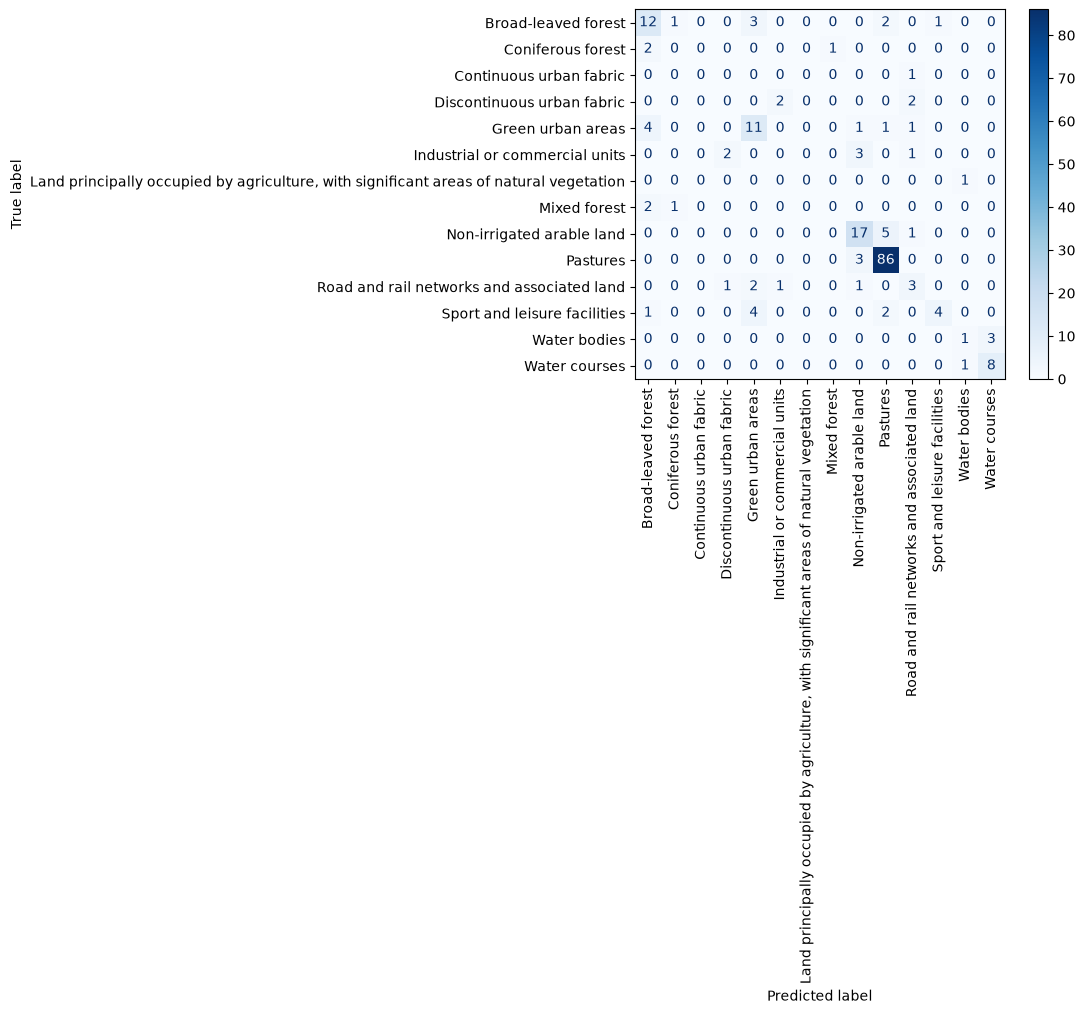

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=le.classes_, cmap='Blues')
d = plt.xticks(rotation=90)

Now, we train the final model:

In [14]:
model.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

## Predictions (mapping)

To produce maps for **all years at once**, we read the full 2015-2019 raster
grid and run :class:`~skmap.io.process.Prediction`.  It concatenates every
year into a single feature matrix (with the static ``elev``/``slope``
covariates repeated for each year) and runs the model **once**, appending
``(n_out · n_years, H*W)`` prediction bands to the raster.  With a label
classifier ``n_out == 1``, so band ``k`` is the map for year ``2015 + k``.


In [15]:
# Read the full multi-year grid (filled NDVI + SWIR1 + statics, 2015-2019)
rdata = rdata.read()

In [17]:
rdata.array.get()

array([[71., 73., 56., ..., 92., 90., 78.],
       [73., 72., 75., ..., 78., 79., 76.],
       [80., 79., 75., ..., 80., 80., 80.],
       ...,
       [60., 57., 58., ..., 51., 51., 49.],
       [47., 45., 43., ..., 64., 64., 65.],
       [10., 14.,  6., ...,  3.,  5.,  2.]],
      shape=(42, 65536), dtype=float32)

In [18]:
from skmap.io.process import Prediction

# One model call predicts all five years; drop_input keeps only predictions.
rdata.run(Prediction(model=model, valid_only=False), drop_input=True)
rdata.info

,group,input_path,input_band,start_date,end_date,temporal,name,band,variant,season,year
0,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-01-01,2015-12-31,True,prediction,NaN,NaN,NaN,2015.0
1,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-01-01,2016-12-31,True,prediction,NaN,NaN,NaN,2016.0
2,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2017-01-01,2017-12-31,True,prediction,NaN,NaN,NaN,2017.0
3,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2018-01-01,2018-12-31,True,prediction,NaN,NaN,NaN,2018.0
4,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2019-01-01,2019-12-31,True,prediction,NaN,NaN,NaN,2019.0


## Visualizing the maps

Finally we plot the predicted land-cover map for each year with
:func:`~skmap.plotter.plot_rasters`.

In [19]:
from matplotlib.colors import ListedColormap

legend = {
	'Broad-leaved forest': '#80FF00',
	'Coniferous forest': '#00A600',
	'Continuous urban fabric': '#558b2f',
	'Discontinuous urban fabric': '#FF0000',
	'Green urban areas': '#FFA6FF',
	'Industrial or commercial units': '#CC4DF2',
	'Land principally occupied by agriculture, with significant areas of natural vegetation': '#E6CC4D',
	'Mixed forest': '#4DFF00',
	'Non-irrigated arable land': '#FFFFA8',
	'Pastures': '#E6E64D',
	'Road and rail networks and associated land': '#CC0000',
	'Sport and leisure facilities': '#FFE6FF',
	'Water bodies': '#80F2E6',
	'Water courses': '#00CCF2'
}

lc_classes = le.classes_
pixel_values = le.transform(lc_classes)
colors = ListedColormap([ legend[c] for c in le.classes_ ])

print("Mapped land cover classes")
for l, p, c in zip(lc_classes, pixel_values, colors.colors):
    print(f' - {l} => pixel value {p} ({c})')

Mapped land cover classes
 - Broad-leaved forest => pixel value 0 (#80FF00)
 - Coniferous forest => pixel value 1 (#00A600)
 - Continuous urban fabric => pixel value 2 (#558b2f)
 - Discontinuous urban fabric => pixel value 3 (#FF0000)
 - Green urban areas => pixel value 4 (#FFA6FF)
 - Industrial or commercial units => pixel value 5 (#CC4DF2)
 - Land principally occupied by agriculture, with significant areas of natural vegetation => pixel value 6 (#E6CC4D)
 - Mixed forest => pixel value 7 (#4DFF00)
 - Non-irrigated arable land => pixel value 8 (#FFFFA8)
 - Pastures => pixel value 9 (#E6E64D)
 - Road and rail networks and associated land => pixel value 10 (#CC0000)
 - Sport and leisure facilities => pixel value 11 (#FFE6FF)
 - Water bodies => pixel value 12 (#80F2E6)
 - Water courses => pixel value 13 (#00CCF2)


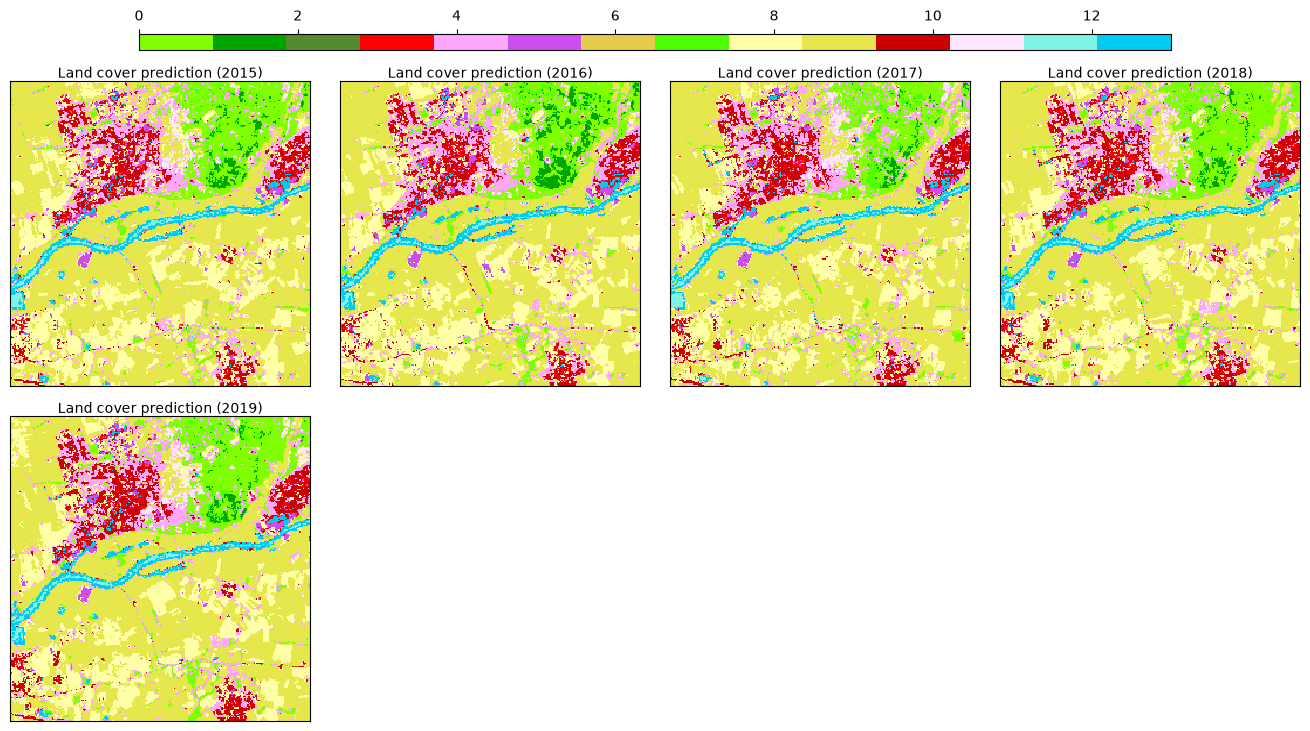

In [20]:
rdata.plot(cmap=colors, img_title_text='Land cover {group} ({year})')